# 1. Introdução
Este projeto visa analisar a evolução das temperaturas médias globais por país ao longo dos anos, utilizando dados da FAO (Food and Agriculture Organization). Serão exploradas variações por país, tendências históricas, tratamento de dados ausentes e outliers, além da criação de novas features para alimentar modelos de machine learning.


### 1.1 Importações

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display


# 2. Coleta e descrição dos dados

### 2.1 Temperatura

Dataset de temperatura carregado com sucesso!

--- Dataset após melt e renomeação de colunas ---
   Area Code      Country  Months Code    Months  Element Code  \
0          2  Afghanistan         7001   January          7271   
1          2  Afghanistan         7001   January          6078   
2          2  Afghanistan         7002  February          7271   
3          2  Afghanistan         7002  February          6078   
4          2  Afghanistan         7003     March          7271   

              Element Unit  Year  Temperature_Change  
0  Temperature change   °C  1961                0.78  
1  Standard Deviation   °C  1961                1.95  
2  Temperature change   °C  1961               -1.74  
3  Standard Deviation   °C  1961                2.60  
4  Temperature change   °C  1961                0.52  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569704 entries, 0 to 569703
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------     

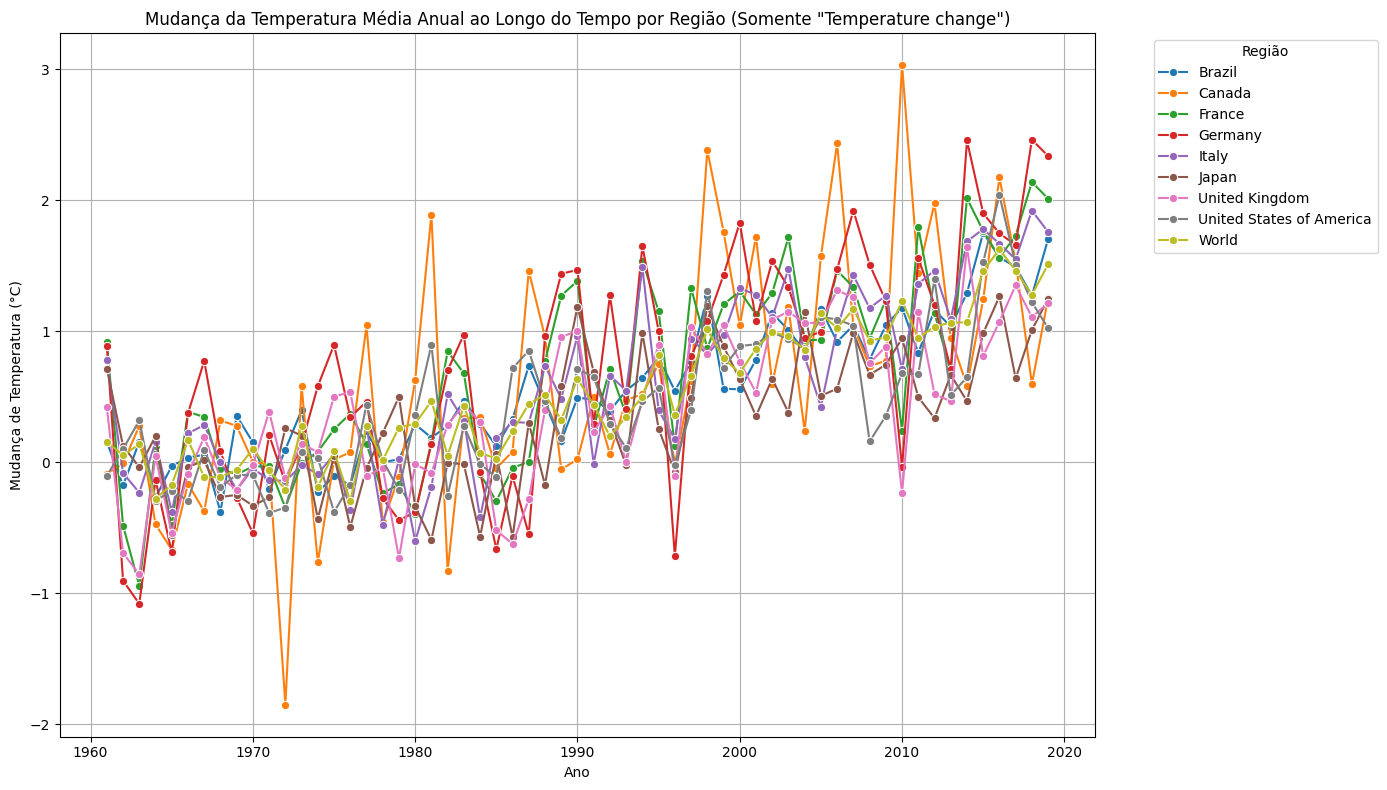

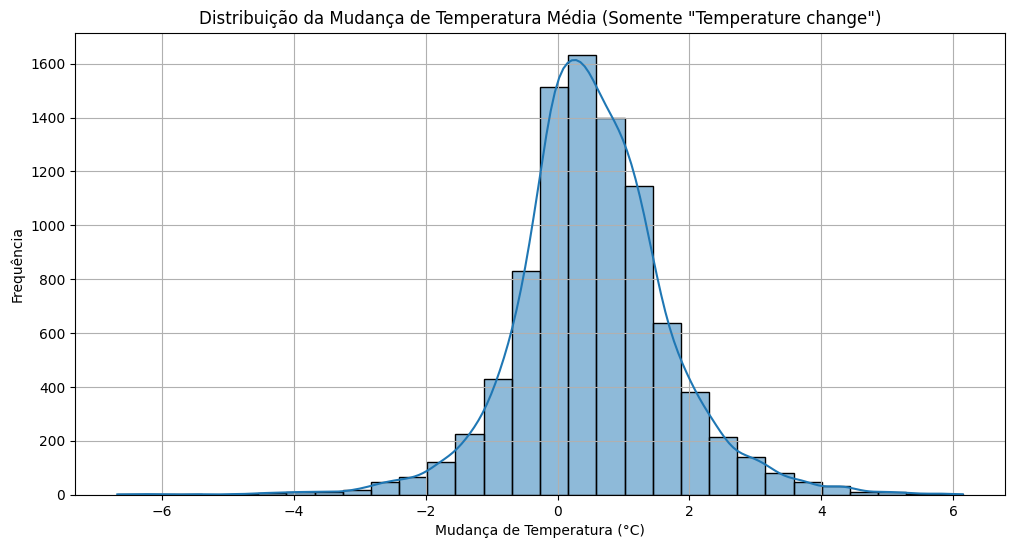

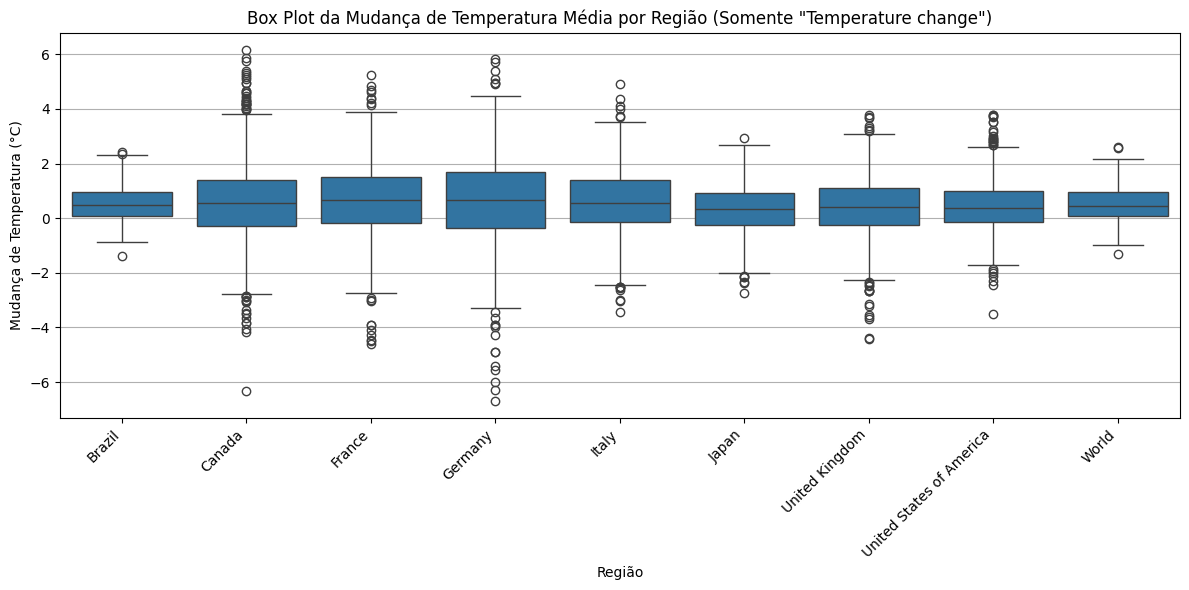


--- Verificando valores ausentes no dataset de temperatura final ---
Area Code             0
Country               0
Months Code           0
Months                0
Element Code          0
Element               0
Unit                  0
Year                  0
Temperature_Change    0
dtype: int64

--- Percentual de valores ausentes ---
Area Code            0.00
Country              0.00
Months Code          0.00
Months               0.00
Element Code         0.00
Element              0.00
Unit                 0.00
Year                 0.00
Temperature_Change   0.00
dtype: float64


In [112]:
# --- 1. Carregamento e Visão Geral Inicial ---
try:
    df = pd.read_csv("../data/Environment_Temperature_change_E_All_Data_NOFLAG.csv", encoding="ISO-8859-1")
    print("Dataset de temperatura carregado com sucesso!")
except FileNotFoundError:
    print("Erro: O arquivo 'Environment_Temperature_change_E_All_Data_NOFLAG.csv' não foi encontrado.")
    exit()

# --- Ajuste para o Formato do Dataset (Melting) ---
year_columns = [col for col in df.columns if col.startswith('Y') and len(col) == 5]
id_vars = [col for col in df.columns if col not in year_columns and 'F' not in col and 'Flag' not in col]

df_melted = df.melt(id_vars=id_vars,
                     value_vars=year_columns,
                     var_name='Year',
                     value_name='Temperature_Change')

df_melted['Year'] = df_melted['Year'].str.replace('Y', '').astype(int)
df_melted.rename(columns={'Area': 'Country'}, inplace=True)

print("\n--- Dataset após melt e renomeação de colunas ---")
print(df_melted.head())
print(df_melted.info())
print("\n--- Valores únicos na coluna 'Element' ---")
print(df_melted['Element'].unique())


# --- 2. Filtragem de Dados de Interesse e do 'Element' ---

# Filtrar para incluir apenas 'Temperature change' na coluna 'Element'
# Esta é a correção principal para esta etapa!
df_filtered_temp = df_melted[df_melted['Element'] == 'Temperature change'].copy()

# Países do G7 e outras regiões de interesse
g7_countries = ['Canada', 'France', 'Germany', 'Italy', 'Japan', 'United Kingdom', 'United States of America']
selected_regions = ['Brazil'] + g7_countries + ['World']

# Filtrar o DataFrame para incluir apenas as regiões de interesse
df_filtered_temp = df_filtered_temp[df_filtered_temp['Country'].isin(selected_regions)].copy()

print(f"\n--- Dataset de temperatura filtrado para as regiões de interesse e 'Temperature change' ({len(df_filtered_temp['Country'].unique())} regiões) ---")
print(df_filtered_temp['Country'].unique())
print(df_filtered_temp.head())
print(df_filtered_temp.info())

# --- 3. Análise Exploratória Detalhada com Visualizações (Parte 1: Tendências Temporais) ---
# Execução dos gráficos novamente para ver o efeito da filtragem do 'Element'

print("\n--- Gerando visualizações de tendências temporais (AGORA COM 'Temperature change' APENAS) ---")

temperature_column = 'Temperature_Change'
df_filtered_temp.dropna(subset=[temperature_column, 'Year'], inplace=True)

plt.figure(figsize=(14, 8))
sns.lineplot(data=df_filtered_temp, x='Year', y=temperature_column, hue='Country', marker='o', errorbar=None)
plt.title(f'Mudança da Temperatura Média Anual ao Longo do Tempo por Região (Somente "Temperature change")')
plt.xlabel('Ano')
plt.ylabel(f'Mudança de Temperatura (°C)')
plt.grid(True)
plt.legend(title='Região', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(df_filtered_temp[temperature_column], kde=True, bins=30)
plt.title(f'Distribuição da Mudança de Temperatura Média (Somente "Temperature change")')
plt.xlabel(f'Mudança de Temperatura (°C)')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x='Country', y=temperature_column, data=df_filtered_temp)
plt.title(f'Box Plot da Mudança de Temperatura Média por Região (Somente "Temperature change")')
plt.xlabel('Região')
plt.ylabel(f'Mudança de Temperatura (°C)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# --- Pré-processamento Adicional: Valores Ausentes e Outliers ---
print("\n--- Verificando valores ausentes no dataset de temperatura final ---")
print(df_filtered_temp.isnull().sum())
print("\n--- Percentual de valores ausentes ---")
print(df_filtered_temp.isnull().sum() / len(df_filtered_temp) * 100)


### 2.2 População

In [ ]:
# --- 2.2 População: Carregamento, Pré-processamento e Merge ---

file_name_pop = "../data/Population_E_All_Data_NOFLAG.csv"

try:
    df_pop = pd.read_csv(file_name_pop, encoding="ISO-8859-1")
    print(f"\n--- Dataset de População '{file_name_pop}' carregado com sucesso! ---")
except FileNotFoundError:
    print(f"Erro: O arquivo '{file_name_pop}' não foi encontrado.")
    # Certifique-se que o caminho está correto ou o arquivo existe
    exit()

print("\n--- Primeiras 5 linhas do DF DE POPULAÇÃO RECÉM-CARREGADO ---")
print(df_pop.head())
print("\n--- Colunas do DF DE POPULAÇÃO RECÉM-CARREGADO ---")
print(df_pop.columns)
print("\n--- Valores únicos da coluna 'Item' no DF DE POPULAÇÃO RECÉM-CARREGADO ---")
if 'Item' in df_pop.columns:
    print(df_pop['Item'].unique())
else:
    print("Coluna 'Item' NÃO encontrada. Verifique o arquivo.")
    exit()

print("\n--- Valores únicos da coluna 'Element' no DF DE POPULAÇÃO RECÉM-CARREGADO ---")
if 'Element' in df_pop.columns:
    print(df_pop['Element'].unique())
else:
    print("Coluna 'Element' NÃO encontrada. Verifique o arquivo.")
    exit()

# Definir colunas de ID para manter e colunas de ano para o melt da população
# Usando as colunas de identificação típicas da FAOSTAT
id_vars_pop = [
    'Area Code', 'Area', 'Item Code', 'Item',
    'Element Code', 'Element', 'Unit'
]
year_columns_pop = [col for col in df_pop.columns if col.startswith('Y') and len(col) == 5]

# Realizar o melt do DataFrame de População
df_melted_pop = df_pop.melt(id_vars=id_vars_pop,
                            value_vars=year_columns_pop,
                            var_name='Year',
                            value_name='Population') # Nome direto 'Population'

# Limpar e converter a coluna 'Year'
df_melted_pop['Year'] = df_melted_pop['Year'].str.replace('Y', '').astype(int)
df_melted_pop.rename(columns={'Area': 'Country'}, inplace=True)

# Filtrar para o 'Element' específico de 'Total Population - Both sexes' e regiões de interesse
population_element = 'Total Population - Both sexes'
if population_element in df_melted_pop['Element'].unique():
    df_filtered_pop = df_melted_pop[df_melted_pop['Element'] == population_element].copy()
else:
    print(f"ERRO: O elemento de população '{population_element}' não foi encontrado na coluna 'Element'.")
    print("Valores disponíveis na coluna 'Element':", df_melted_pop['Element'].unique())
    exit() # Interromper se o filtro essencial não for encontrado

# Filtrar para as mesmas regiões de interesse usadas para a temperatura
# (Re-definir g7_countries e selected_regions para garantir escopo)
g7_countries = ['Canada', 'France', 'Germany', 'Italy', 'Japan', 'United Kingdom', 'United States of America']
selected_regions = ['Brazil'] + g7_countries + ['World']

df_filtered_pop = df_filtered_pop[df_filtered_pop['Country'].isin(selected_regions)].copy()
df_filtered_pop.dropna(subset=['Population', 'Year'], inplace=True) # Remover NaN da população e ano

# Selecionar apenas as colunas essenciais antes do merge
df_filtered_pop = df_filtered_pop[['Country', 'Year', 'Population']]

print("\n--- Dataset de População Processado e Filtrado (df_filtered_pop) ---")
print(df_filtered_pop.head())
print(df_filtered_pop.info())
print("\n--- Valores ausentes no df_filtered_pop ---")
print(df_filtered_pop.isnull().sum())

# --- Merge do Dataset de Temperatura com o de População ---
# df_filtered_temp deve estar definido da célula de processamento de temperatura
df_merged_temp_pop = pd.merge(df_filtered_temp, df_filtered_pop, on=['Country', 'Year'], how='left')

print("\n--- Primeiras 5 linhas do Dataset TEMP + POP (df_merged_temp_pop) ---")
print(df_merged_temp_pop.head())
print("\n--- Informações do Dataset TEMP + POP ---")
print(df_merged_temp_pop.info())
print("\n--- Valores ausentes no Dataset TEMP + POP ---")
print(df_merged_temp_pop.isnull().sum())
print("\n--- Percentual de valores ausentes no Dataset TEMP + POP ---")
print(df_merged_temp_pop.isnull().sum() / len(df_merged_temp_pop) * 100)


--- Dataset de População '../data/Population_E_All_Data_NOFLAG.csv' carregado com sucesso! ---

--- Primeiras 5 linhas do DF DE POPULAÇÃO RECÉM-CARREGADO ---
   Area Code Area Code (M49)         Area  Item Code  \
0          2            '004  Afghanistan       3010   
1          2            '004  Afghanistan       3010   
2          2            '004  Afghanistan       3010   
3          2            '004  Afghanistan       3010   
4          2            '004  Afghanistan       3010   

                        Item  Element Code                        Element  \
0  Population - Est. & Proj.           511  Total Population - Both sexes   
1  Population - Est. & Proj.           512        Total Population - Male   
2  Population - Est. & Proj.           513      Total Population - Female   
3  Population - Est. & Proj.           551               Rural population   
4  Population - Est. & Proj.           561               Urban population   

      Unit   Y1950   Y1951  ...     Y2091

### 2.3 Indicadores de Emissão de Gases

In [114]:
# --- 2.3 Indicadores de Emissão de Gases: Carregamento, Pré-processamento e Merge ---

file_name_emissions = "../data/Emissions_Totals_E_All_Data_NOFLAG.csv"

try:
    df_emissions = pd.read_csv(file_name_emissions, encoding="ISO-8859-1")
    print(f"\nDataset de Emissões '{file_name_emissions}' carregado com sucesso.")

    # Melt das colunas de ano
    id_vars_emissions = [
        'Area Code', 'Area', 'Item Code', 'Item',
        'Element Code', 'Element', 'Unit'
    ]
    year_columns_emissions = [col for col in df_emissions.columns if col.startswith('Y') and len(col) == 5]

    df_melted_emissions = df_emissions.melt(
        id_vars=id_vars_emissions,
        value_vars=year_columns_emissions,
        var_name='Year',
        value_name='CO2_Emissions'
    )

    df_melted_emissions['Year'] = df_melted_emissions['Year'].str.replace('Y', '').astype(int)
    df_melted_emissions.rename(columns={'Area': 'Country'}, inplace=True)

    # Filtros por item e elemento
    emissions_item = 'All sectors without LULUCF'
    element_type = 'Emissions (CO2)'

    if emissions_item not in df_melted_emissions['Item'].unique():
        raise ValueError(f"Item '{emissions_item}' não encontrado na coluna 'Item'.")

    if element_type not in df_melted_emissions['Element'].unique():
        raise ValueError(f"Elemento '{element_type}' não encontrado na coluna 'Element'.")

    df_filtered_emissions = df_melted_emissions[
        (df_melted_emissions['Item'] == emissions_item) &
        (df_melted_emissions['Element'] == element_type)
    ].copy()

    # Países e regiões de interesse
    g7_countries = ['Canada', 'France', 'Germany', 'Italy', 'Japan', 'United Kingdom', 'United States of America']
    selected_regions = ['Brazil'] + g7_countries + ['World']

    df_filtered_emissions = df_filtered_emissions[df_filtered_emissions['Country'].isin(selected_regions)]
    df_filtered_emissions.dropna(subset=['CO2_Emissions', 'Year'], inplace=True)

    df_filtered_emissions = df_filtered_emissions[['Country', 'Year', 'CO2_Emissions']]

    print("\nDataset de Emissões Processado e Filtrado (df_filtered_emissions):")
    display(df_filtered_emissions.head())

    print("\nValores ausentes:")
    print(df_filtered_emissions.isnull().sum())

    # Merge com temperatura e população
    df_merged_temp_pop_emiss = pd.merge(
        df_merged_temp_pop,
        df_filtered_emissions,
        on=['Country', 'Year'],
        how='left'
    )

    print("\nMerge com df_merged_temp_pop concluído com sucesso.")
    display(df_merged_temp_pop_emiss.head())

except Exception as e:
    print(f"Erro ao processar dados de emissões: {e}")


Dataset de Emissões '../data/Emissions_Totals_E_All_Data_NOFLAG.csv' carregado com sucesso.

Dataset de Emissões Processado e Filtrado (df_filtered_emissions):


,Country,Year,CO2_Emissions
1893241,Brazil,1990,226119.13
1895422,Canada,1990,453655.13
1905050,France,1990,392823.89
1906425,Germany,1990,1047908.40
1911899,Italy,1990,428842.01



Valores ausentes:
Country          0
Year             0
CO2_Emissions    0
dtype: int64

Merge com df_merged_temp_pop concluído com sucesso.


,Area Code,Country,Months Code,Months,Element Code,Element,Unit,Year,Temperature_Change,Population,CO2_Emissions
0,21,Brazil,7001,January,7271,Temperature change,°C,1961,-0.11,74605.45,NaN
1,21,Brazil,7002,February,7271,Temperature change,°C,1961,-0.24,74605.45,NaN
2,21,Brazil,7003,March,7271,Temperature change,°C,1961,-0.02,74605.45,NaN
3,21,Brazil,7004,April,7271,Temperature change,°C,1961,0.22,74605.45,NaN
4,21,Brazil,7005,May,7271,Temperature change,°C,1961,0.33,74605.45,NaN


### 2.4 PIB per-capita

In [115]:
# --- 2.4 Indicadores Econômicos: PIB per capita (Carregamento, Pré-processamento e Merge) ---

file_name_pib = "../data/pib_percapita.csv"

try:
    # Carregar o arquivo com tratamento especial para o formato
    df_pib = pd.read_csv(file_name_pib, encoding="utf-8", skiprows=4)
    
    # Verificar as colunas existentes
    print("Colunas disponíveis no DataFrame:")
    print(df_pib.columns.tolist())
    
    # Renomear coluna de país
    df_pib = df_pib.rename(columns={'Country Name': 'Country'})
    
    # Identificar colunas de ano (que são numéricas)
    year_cols = [col for col in df_pib.columns if col.isdigit()]
    non_year_cols = [col for col in df_pib.columns if not col.isdigit()]
    
    # Manter apenas colunas necessárias
    keep_cols = ['Country'] + year_cols
    df_pib = df_pib[keep_cols]
    
    # Derreter o dataframe para formato longo
    df_melted_pib = df_pib.melt(
        id_vars=['Country'],
        value_vars=year_cols,
        var_name='Year',
        value_name='GDP_per_capita'
    )
    
    # Converter ano para inteiro
    df_melted_pib['Year'] = df_melted_pib['Year'].astype(int)
    
    # Filtrar países de interesse
    g7_countries = ['Canada', 'France', 'Germany', 'Italy', 'Japan', 'United Kingdom', 'United States']
    selected_regions = ['Brazil'] + g7_countries + ['World']
    
    # Ajustar nomes de países para correspondência
    country_mapping = {
        'United States': 'United States of America',
        'Korea, Rep.': 'South Korea'  # Exemplo adicional se necessário
    }
    
    df_melted_pib['Country'] = df_melted_pib['Country'].replace(country_mapping)
    
    df_filtered_pib = df_melted_pib[df_melted_pib['Country'].isin(selected_regions)].copy()
    df_filtered_pib.dropna(subset=['GDP_per_capita'], inplace=True)
    
    # Verificar os dados antes do merge
    print("\nDataset de PIB per capita processado (df_filtered_pib):")
    print(f"Registros encontrados: {len(df_filtered_pib)}")
    display(df_filtered_pib.head())
    
    # Verificar países presentes
    print("\nPaíses encontrados nos dados de PIB:")
    print(df_filtered_pib['Country'].unique())
    
    # Merge com o dataframe consolidado anterior
    df_final = pd.merge(
        df_merged_temp_pop_emiss,
        df_filtered_pib,
        on=['Country', 'Year'],
        how='left'
    )
    
    print("\nMerge com dados de PIB per capita concluído com sucesso.")
    print(f"Shape do dataframe final: {df_final.shape}")
    print("\nAmostra do dataframe final:")
    display(df_final.head())
    
    # Verificar valores ausentes
    print("\nValores ausentes por coluna:")
    print(df_final.isnull().sum())

except Exception as e:
    print(f"\nErro ao processar dados de PIB per capita: {e}")
    
    # Diagnóstico adicional
    print("\nInformações para diagnóstico:")
    print(f"Arquivo sendo lido: {file_name_pib}")
    print(f"Encoding tentado: utf-8")
    
    try:
        # Verificar estrutura do arquivo
        with open(file_name_pib, 'r', encoding='utf-8') as f:
            print("\nEstrutura do arquivo:")
            for i, line in enumerate(f):
                if i < 10:  # Mostrar apenas as primeiras 10 linhas
                    print(f"Linha {i+1}: {line.strip()}")
                else:
                    break
    except Exception as file_error:
        print(f"\nErro ao tentar ler o arquivo para diagnóstico: {file_error}")

Colunas disponíveis no DataFrame:
['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', 'Unnamed: 69']

Dataset de PIB per capita processado (df_filtered_pib):
Registros encontrados: 512


,Country,Year,GDP_per_capita
29,Brazil,1960,235.27
35,Canada,1960,2264.95
55,Germany,1960,1162.12
77,France,1960,1302.53
81,United Kingdom,1960,1397.59



Países encontrados nos dados de PIB:
['Brazil' 'Canada' 'Germany' 'France' 'United Kingdom' 'Italy' 'Japan'
 'World']

Merge com dados de PIB per capita concluído com sucesso.
Shape do dataframe final: (9027, 12)

Amostra do dataframe final:


,Area Code,Country,Months Code,Months,Element Code,Element,Unit,Year,Temperature_Change,Population,CO2_Emissions,GDP_per_capita
0,21,Brazil,7001,January,7271,Temperature change,°C,1961,-0.11,74605.45,NaN,231.56
1,21,Brazil,7002,February,7271,Temperature change,°C,1961,-0.24,74605.45,NaN,231.56
2,21,Brazil,7003,March,7271,Temperature change,°C,1961,-0.02,74605.45,NaN,231.56
3,21,Brazil,7004,April,7271,Temperature change,°C,1961,0.22,74605.45,NaN,231.56
4,21,Brazil,7005,May,7271,Temperature change,°C,1961,0.33,74605.45,NaN,231.56



Valores ausentes por coluna:
Area Code                0
Country                  0
Months Code              0
Months                   0
Element Code             0
Element                  0
Unit                     0
Year                     0
Temperature_Change       0
Population            1003
CO2_Emissions         4947
GDP_per_capita        1003
dtype: int64


In [116]:
# --- 2.4.1 Engenharia de Features Derivadas ---

# Garantir ordenação para cálculo correto de diferenças e médias móveis
df_final = df_final.sort_values(by=['Country', 'Year'])

# Variação ano a ano de emissões e PIB per capita
df_final['CO2_Emissions_diff'] = df_final.groupby('Country')['CO2_Emissions'].diff()
df_final['GDP_per_capita_diff'] = df_final.groupby('Country')['GDP_per_capita'].diff()

# Média móvel de 5 anos da mudança de temperatura
df_final['Temperature_Change_rolling_mean'] = df_final.groupby('Country')['Temperature_Change']\
    .transform(lambda x: x.rolling(window=5, min_periods=1).mean())

# Emissão per capita e sua média móvel
df_final['CO2_per_capita'] = df_final['CO2_Emissions'] / df_final['Population']
df_final['CO2_per_capita_rolling_mean'] = df_final.groupby('Country')['CO2_per_capita']\
    .transform(lambda x: x.rolling(window=5, min_periods=1).mean())

# PIB per capita comparado à média global no mesmo ano
gdp_global = df_final[df_final['Country'] == 'World'][['Year', 'GDP_per_capita']]\
    .rename(columns={'GDP_per_capita': 'GDP_global'})
df_final = pd.merge(df_final, gdp_global, on='Year', how='left')
df_final['GDP_vs_global'] = df_final['GDP_per_capita'] / df_final['GDP_global']


### 2.5 Análise Detalhada dos Dados Consolidados

In [117]:
# Verificando a estrutura do dataset consolidado
print("\n--- Estrutura do Dataset Consolidado ---")
print(f"Dimensões do dataset: {df_final.shape}")
print("\nInformações sobre as colunas:")
print(df_final.info())
print("\nPrimeiras 5 linhas:")
display(df_final.head())
print("\nÚltimas 5 linhas:")
display(df_final.tail())


--- Estrutura do Dataset Consolidado ---
Dimensões do dataset: (153459, 19)

Informações sobre as colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153459 entries, 0 to 153458
Data columns (total 19 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Area Code                        153459 non-null  int64  
 1   Country                          153459 non-null  object 
 2   Months Code                      153459 non-null  int64  
 3   Months                           153459 non-null  object 
 4   Element Code                     153459 non-null  int64  
 5   Element                          153459 non-null  object 
 6   Unit                             153459 non-null  object 
 7   Year                             153459 non-null  int64  
 8   Temperature_Change               153459 non-null  float64
 9   Population                       136408 non-null  float64
 10  CO2_Emissions       

,Area Code,Country,Months Code,Months,Element Code,Element,Unit,Year,Temperature_Change,Population,CO2_Emissions,GDP_per_capita,CO2_Emissions_diff,GDP_per_capita_diff,Temperature_Change_rolling_mean,CO2_per_capita,CO2_per_capita_rolling_mean,GDP_global,GDP_vs_global
0,21,Brazil,7001,January,7271,Temperature change,°C,1961,-0.11,74605.45,NaN,231.56,NaN,NaN,-0.11,NaN,NaN,472.11,0.49
1,21,Brazil,7001,January,7271,Temperature change,°C,1961,-0.11,74605.45,NaN,231.56,NaN,NaN,-0.11,NaN,NaN,472.11,0.49
2,21,Brazil,7001,January,7271,Temperature change,°C,1961,-0.11,74605.45,NaN,231.56,NaN,NaN,-0.11,NaN,NaN,472.11,0.49
3,21,Brazil,7001,January,7271,Temperature change,°C,1961,-0.11,74605.45,NaN,231.56,NaN,NaN,-0.11,NaN,NaN,472.11,0.49
4,21,Brazil,7001,January,7271,Temperature change,°C,1961,-0.11,74605.45,NaN,231.56,NaN,NaN,-0.11,NaN,NaN,472.11,0.49



Últimas 5 linhas:


,Area Code,Country,Months Code,Months,Element Code,Element,Unit,Year,Temperature_Change,Population,CO2_Emissions,GDP_per_capita,CO2_Emissions_diff,GDP_per_capita_diff,Temperature_Change_rolling_mean,CO2_per_capita,CO2_per_capita_rolling_mean,GDP_global,GDP_vs_global
153454,5000,World,7020,Meteorological year,7271,Temperature change,°C,2019,1.47,7811293.16,37037100.92,11334.84,0.00,0.00,1.47,4.74,4.74,11334.84,1.00
153455,5000,World,7020,Meteorological year,7271,Temperature change,°C,2019,1.47,7811293.16,37037100.92,11334.84,0.00,0.00,1.47,4.74,4.74,11334.84,1.00
153456,5000,World,7020,Meteorological year,7271,Temperature change,°C,2019,1.47,7811293.16,37037100.92,11334.84,0.00,0.00,1.47,4.74,4.74,11334.84,1.00
153457,5000,World,7020,Meteorological year,7271,Temperature change,°C,2019,1.47,7811293.16,37037100.92,11334.84,0.00,0.00,1.47,4.74,4.74,11334.84,1.00
153458,5000,World,7020,Meteorological year,7271,Temperature change,°C,2019,1.47,7811293.16,37037100.92,11334.84,0.00,0.00,1.47,4.74,4.74,11334.84,1.00



--- Análise de Valores Ausentes ---
                                 Quantidade  Percentual
Area Code                                 0        0.00
Country                                   0        0.00
Months Code                               0        0.00
Months                                    0        0.00
Element Code                              0        0.00
Element                                   0        0.00
Unit                                      0        0.00
Year                                      0        0.00
Temperature_Change                        0        0.00
Population                            17051       11.11
CO2_Emissions                         84099       54.80
GDP_per_capita                        17051       11.11
CO2_Emissions_diff                    84235       54.89
GDP_per_capita_diff                   17187       11.20
Temperature_Change_rolling_mean           0        0.00
CO2_per_capita                        84099       54.80
CO2_per_cap

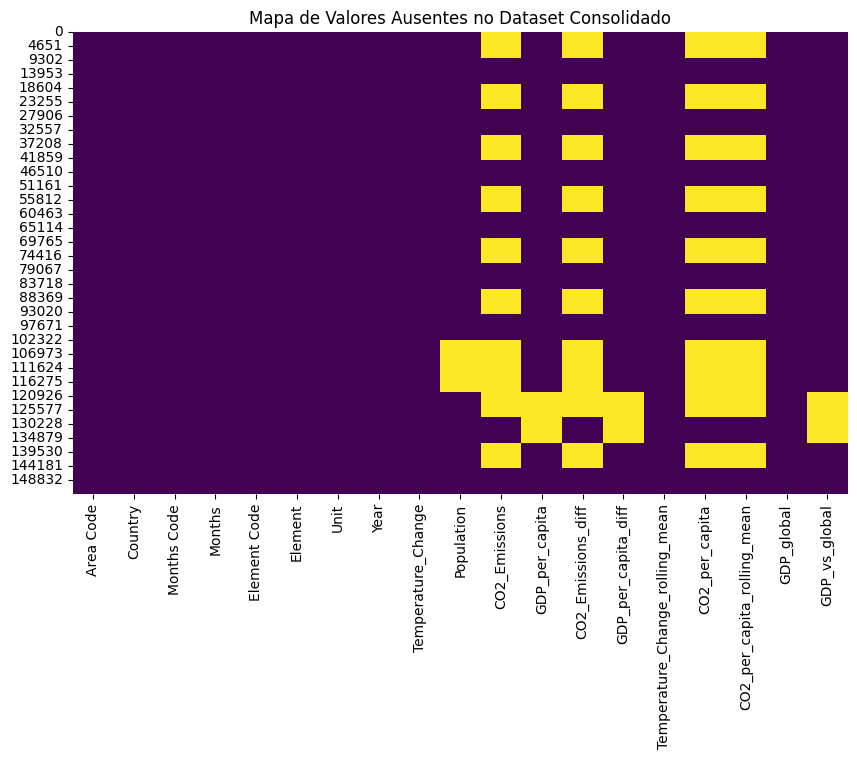

In [118]:
# Análise detalhada de valores ausentes
print("\n--- Análise de Valores Ausentes ---")
missing_data = df_final.isnull().sum()
missing_percent = (df_final.isnull().sum() / len(df_final)) * 100
missing_analysis = pd.concat([missing_data, missing_percent], axis=1)
missing_analysis.columns = ['Quantidade', 'Percentual']
print(missing_analysis)

# Visualização dos valores ausentes
plt.figure(figsize=(10, 6))
sns.heatmap(df_final.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de Valores Ausentes no Dataset Consolidado')
plt.show()


--- Estatísticas Descritivas ---
        Area Code Country  Months Code   Months  Element Code  \
count   153459.00  153459    153459.00   153459     153459.00   
unique        NaN       9          NaN       17           NaN   
top           NaN  Brazil          NaN  January           NaN   
freq          NaN   17051          NaN     9027           NaN   
mean       653.00     NaN      7009.88      NaN       7271.00   
std       1538.54     NaN         6.04      NaN          0.00   
min         21.00     NaN      7001.00      NaN       7271.00   
25%         68.00     NaN      7005.00      NaN       7271.00   
50%        106.00     NaN      7009.00      NaN       7271.00   
75%        229.00     NaN      7016.00      NaN       7271.00   
max       5000.00     NaN      7020.00      NaN       7271.00   

                   Element    Unit      Year  Temperature_Change  Population  \
count               153459  153459 153459.00           153459.00   136408.00   
unique                   

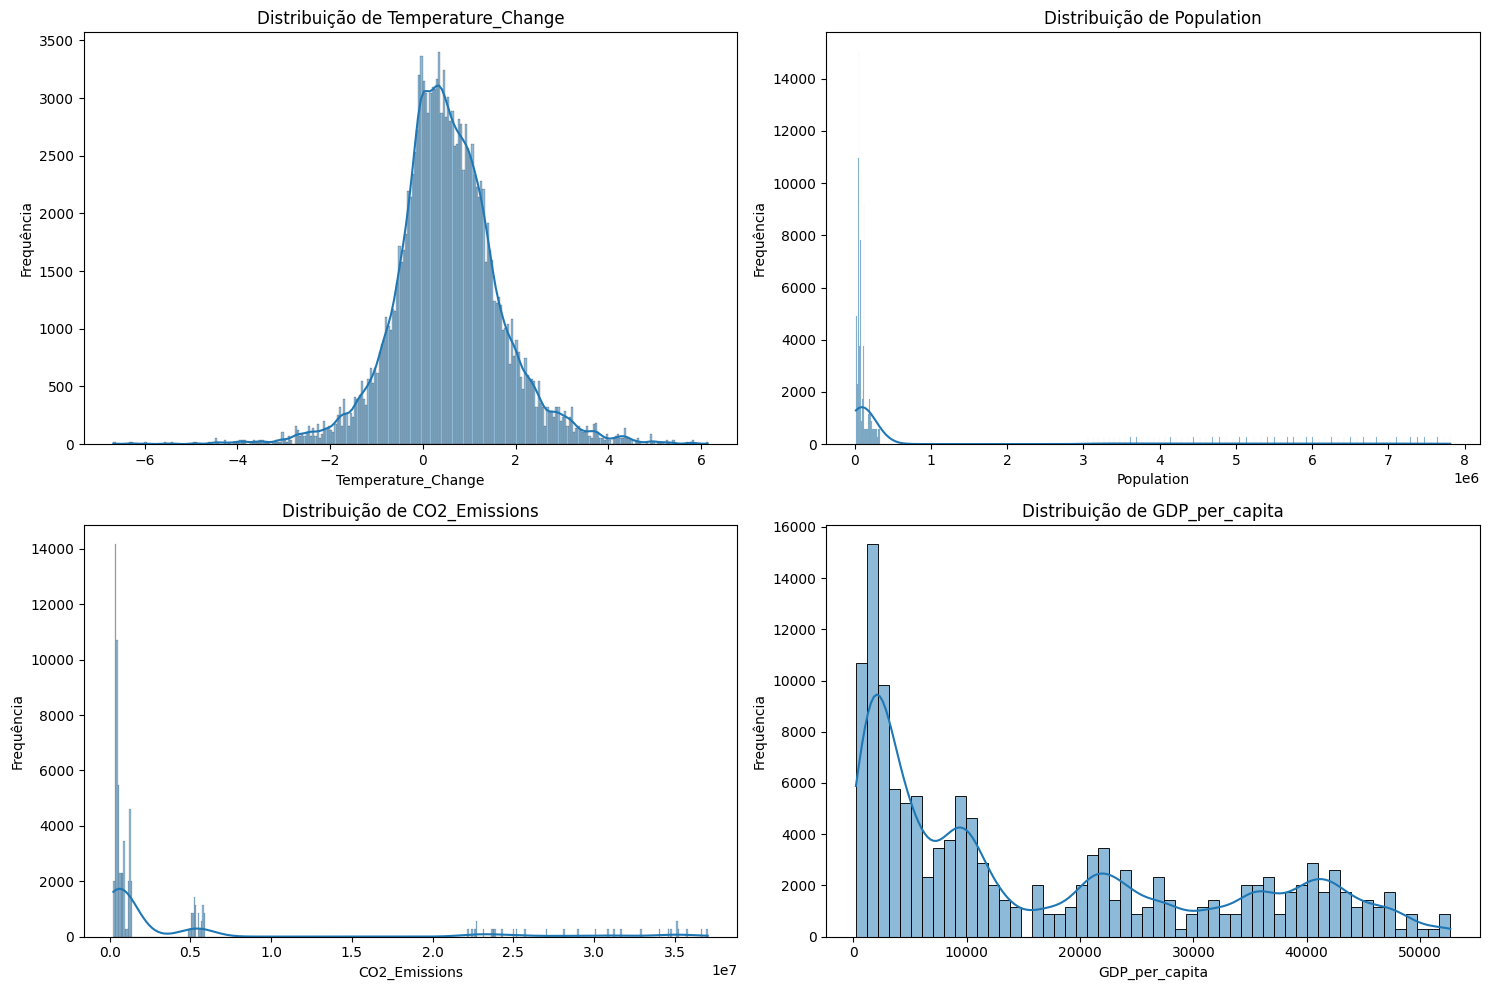

In [119]:
# Estatísticas descritivas
print("\n--- Estatísticas Descritivas ---")
print(df_final.describe(include='all'))

# Distribuição das variáveis numéricas
num_cols = ['Temperature_Change', 'Population', 'CO2_Emissions', 'GDP_per_capita']
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_final[col], kde=True)
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

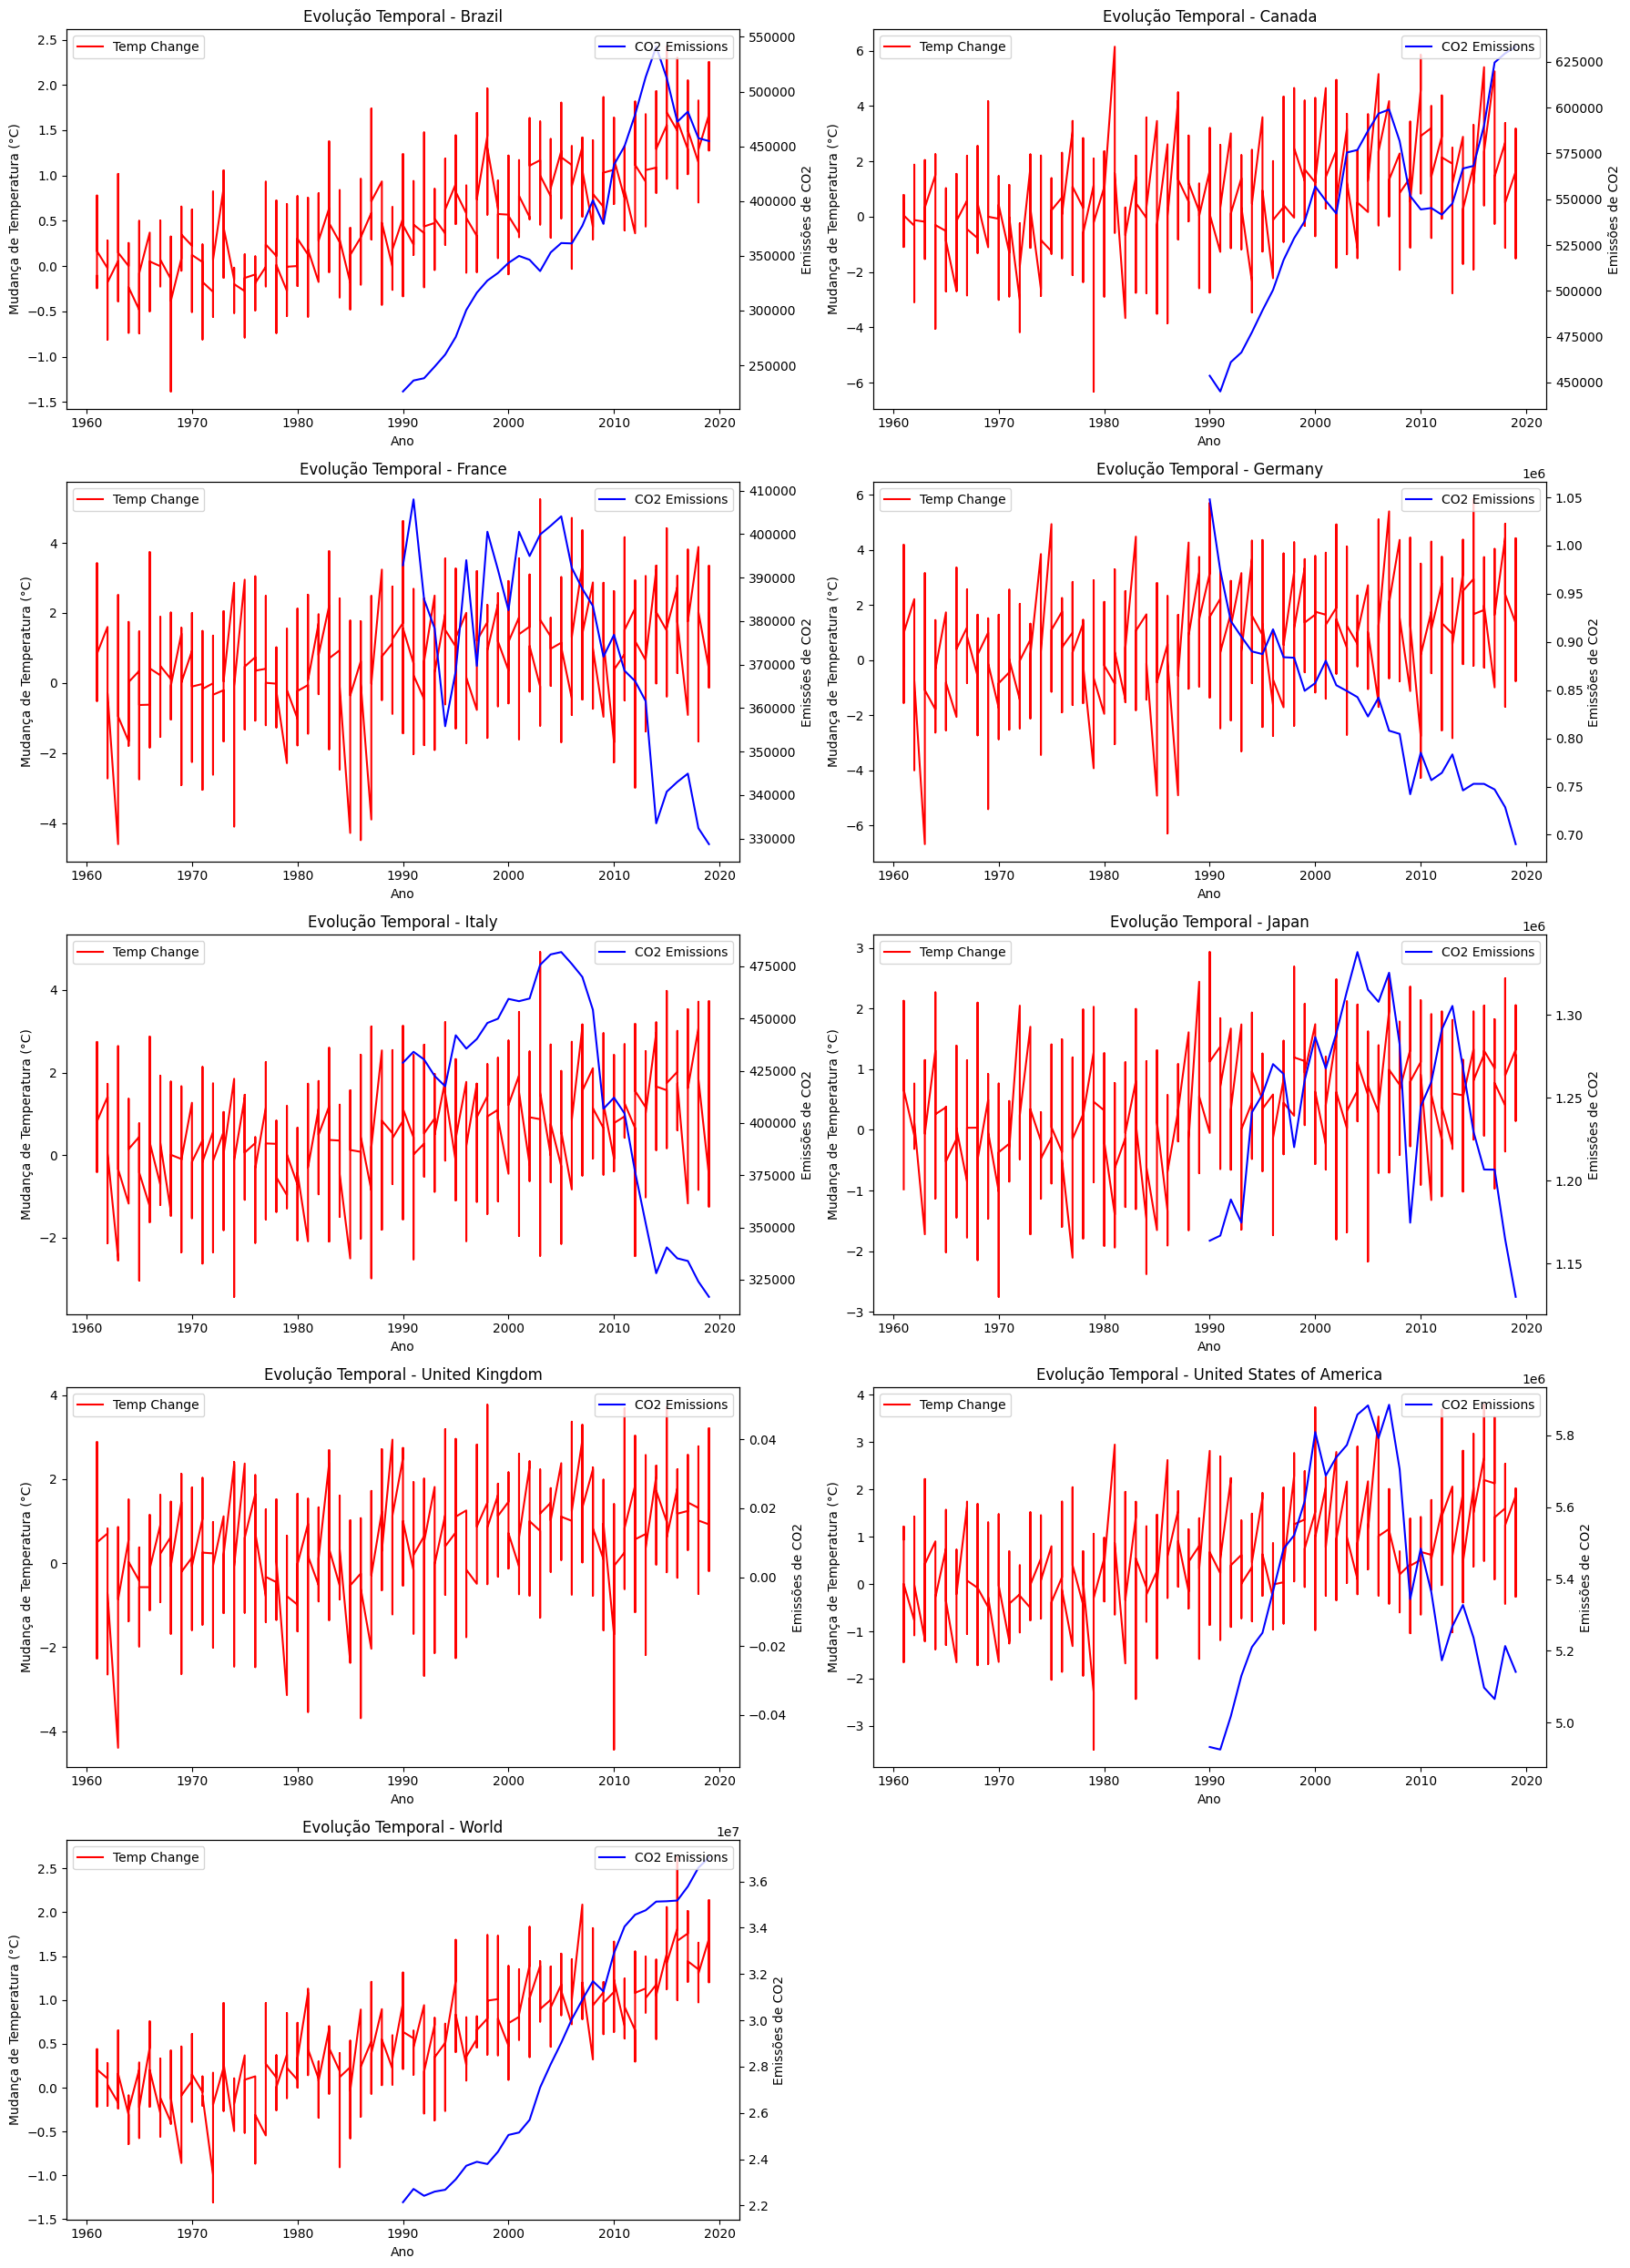

In [120]:
countries = df_final['Country'].unique()
n_countries = len(countries)
n_rows = (n_countries + 1) // 2  # Calcula o número necessário de linhas

plt.figure(figsize=(18, 5*n_rows))  # Ajusta a altura dinamicamente
for i, country in enumerate(countries, 1):
    country_data = df_final[df_final['Country'] == country]
    
    plt.subplot(n_rows, 2, i)  # Layout dinâmico baseado no número de países
    plt.plot(country_data['Year'], country_data['Temperature_Change'], label='Temp Change', color='red')
    plt.title(f'Evolução Temporal - {country}')
    plt.xlabel('Ano')
    plt.ylabel('Mudança de Temperatura (°C)')
    plt.legend(loc='upper left')
    
    ax2 = plt.twinx()
    ax2.plot(country_data['Year'], country_data['CO2_Emissions'], label='CO2 Emissions', color='blue')
    ax2.set_ylabel('Emissões de CO2')
    ax2.legend(loc='upper right')
    
plt.tight_layout()
plt.show()


--- Matriz de Correlação ---
                    Temperature_Change  Population  CO2_Emissions  \
Temperature_Change                1.00        0.03          -0.02   
Population                        0.03        1.00           0.99   
CO2_Emissions                    -0.02        0.99           1.00   
GDP_per_capita                    0.35       -0.27          -0.49   

                    GDP_per_capita  
Temperature_Change            0.35  
Population                   -0.27  
CO2_Emissions                -0.49  
GDP_per_capita                1.00  


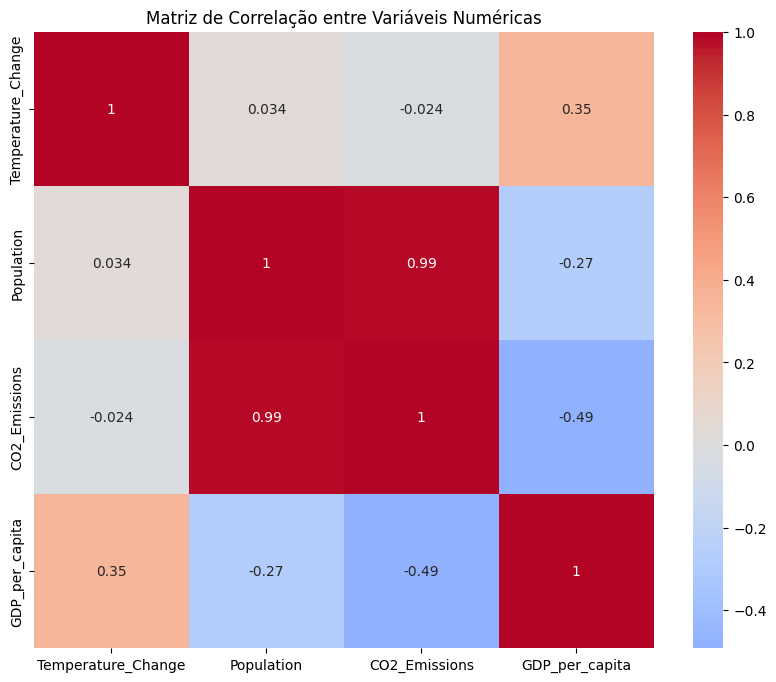

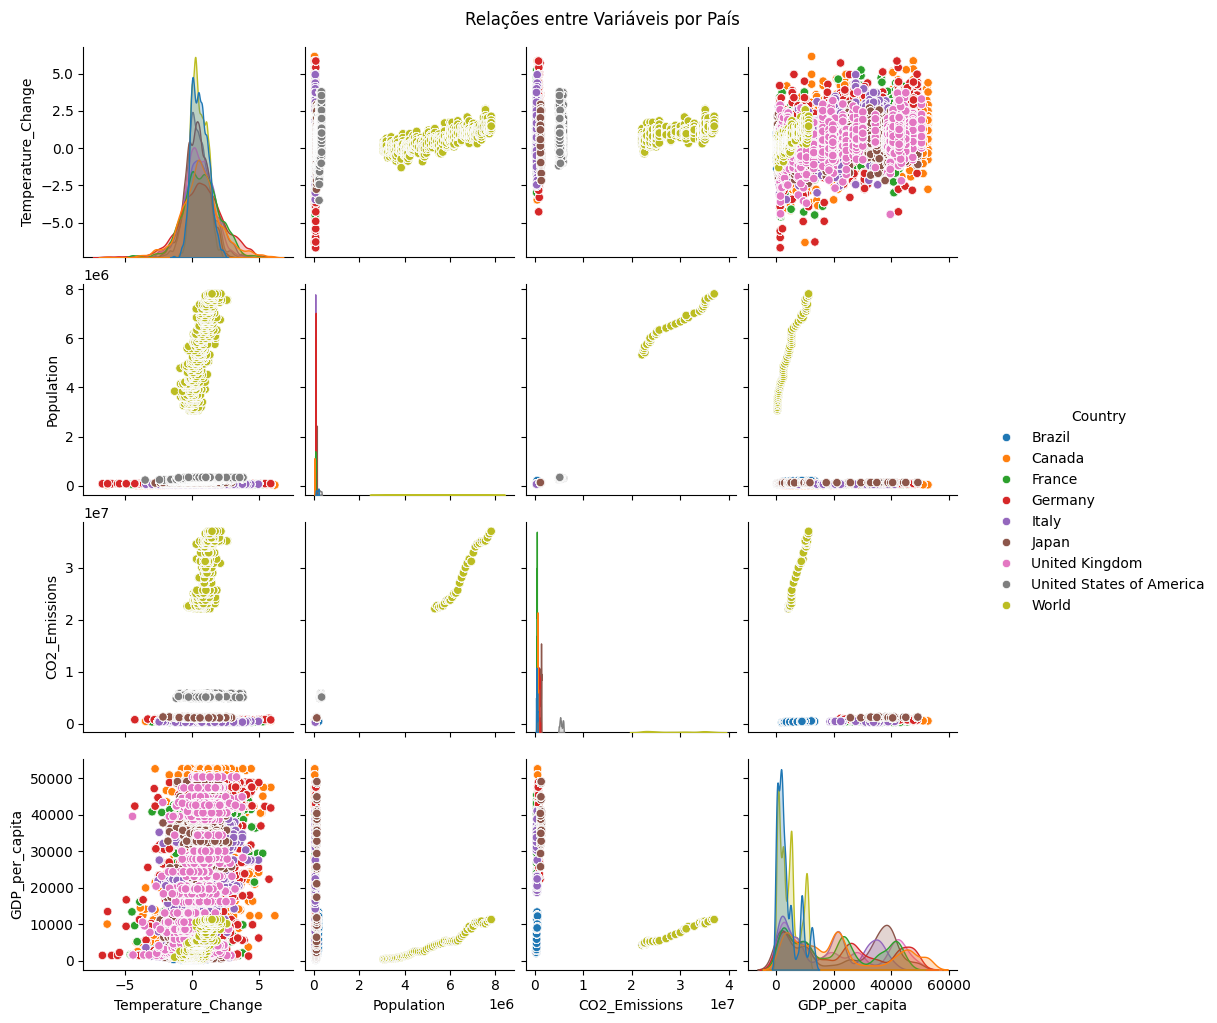

In [121]:
# Matriz de correlação
print("\n--- Matriz de Correlação ---")
correlation_matrix = df_final[num_cols].corr()
print(correlation_matrix)

# Heatmap de correlações
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.show()

# Pairplot para visualizar relações
sns.pairplot(df_final[num_cols + ['Country']], hue='Country', diag_kind='kde')
plt.suptitle('Relações entre Variáveis por País', y=1.02)
plt.show()

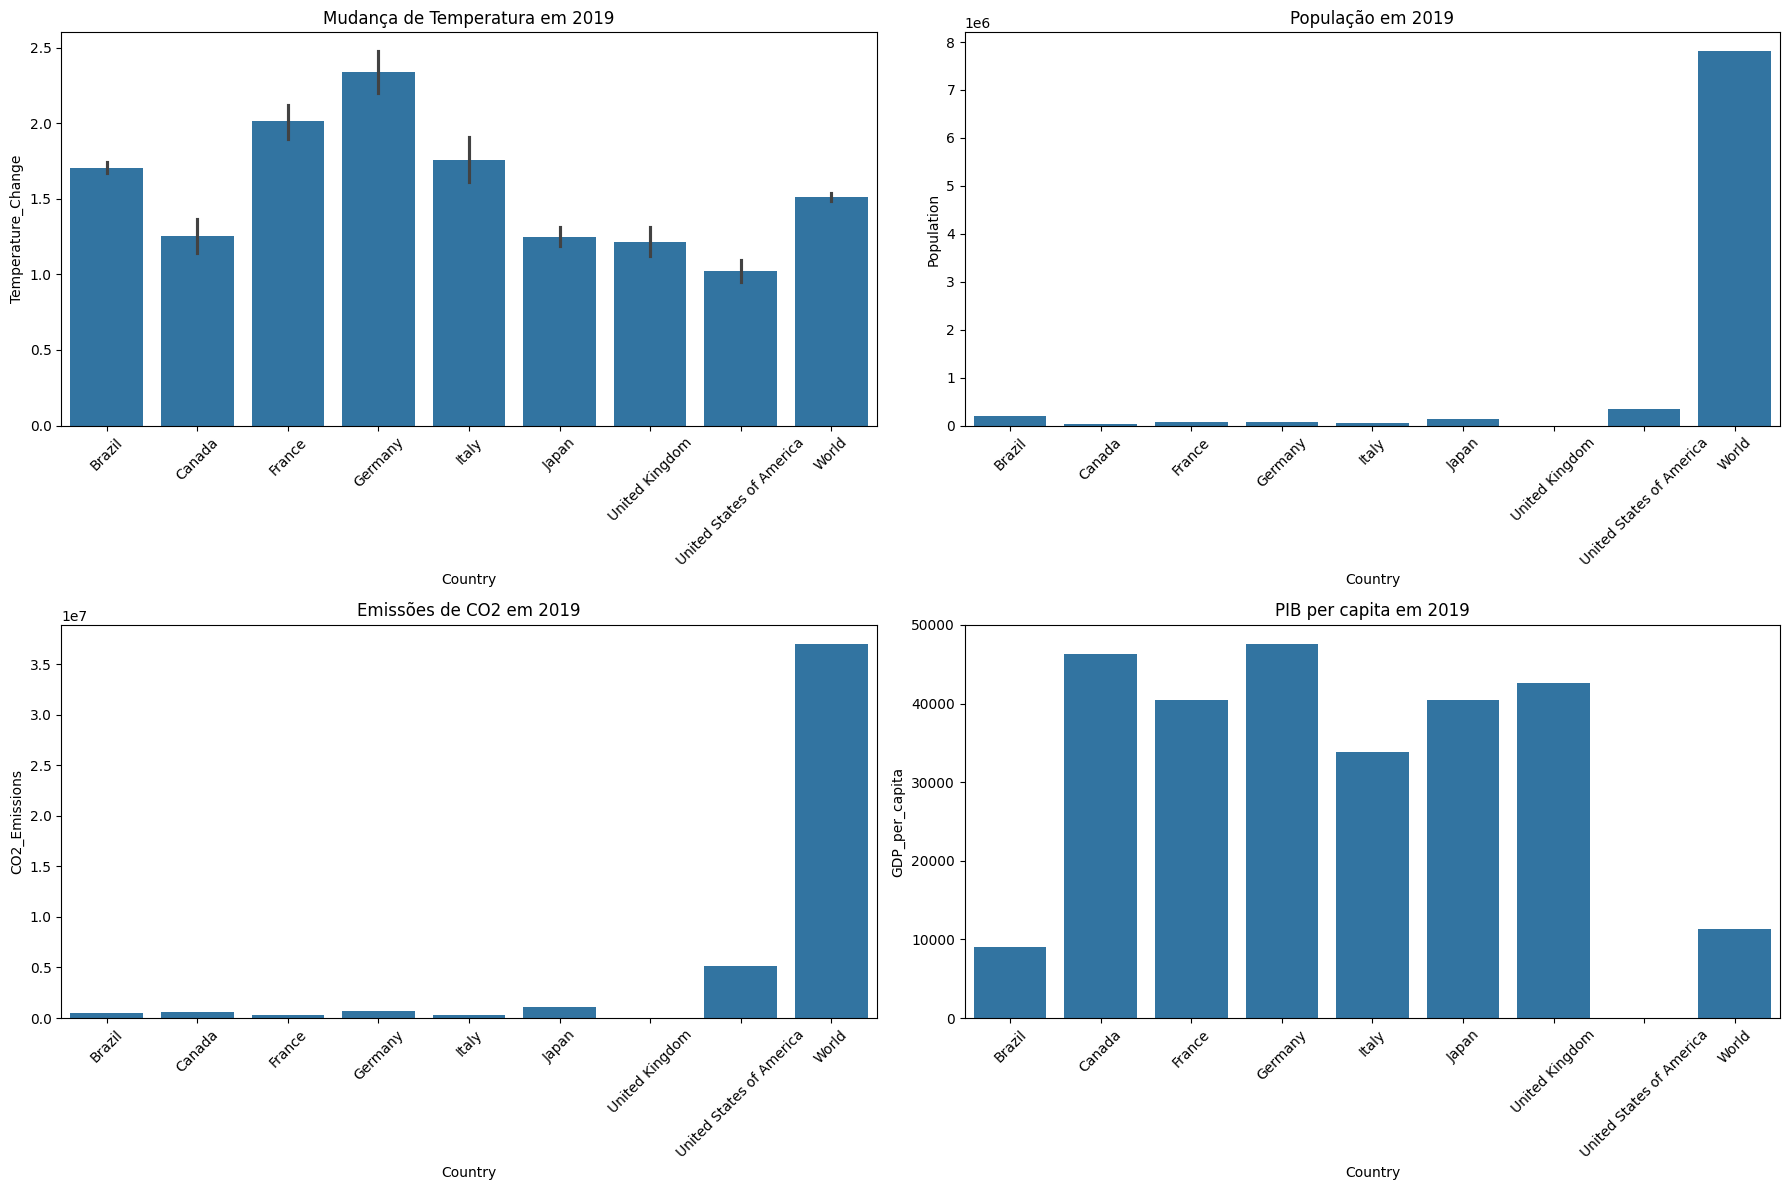

In [122]:
# Comparação entre países para o ano mais recente
latest_year = df_final['Year'].max()
latest_data = df_final[df_final['Year'] == latest_year]

# Criando subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Temperatura
sns.barplot(ax=axes[0, 0], x='Country', y='Temperature_Change', data=latest_data)
axes[0, 0].set_title(f'Mudança de Temperatura em {latest_year}')
axes[0, 0].tick_params(axis='x', rotation=45)

# População
sns.barplot(ax=axes[0, 1], x='Country', y='Population', data=latest_data)
axes[0, 1].set_title(f'População em {latest_year}')
axes[0, 1].tick_params(axis='x', rotation=45)

# Emissões de CO2
sns.barplot(ax=axes[1, 0], x='Country', y='CO2_Emissions', data=latest_data)
axes[1, 0].set_title(f'Emissões de CO2 em {latest_year}')
axes[1, 0].tick_params(axis='x', rotation=45)

# PIB per capita
sns.barplot(ax=axes[1, 1], x='Country', y='GDP_per_capita', data=latest_data)
axes[1, 1].set_title(f'PIB per capita em {latest_year}')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

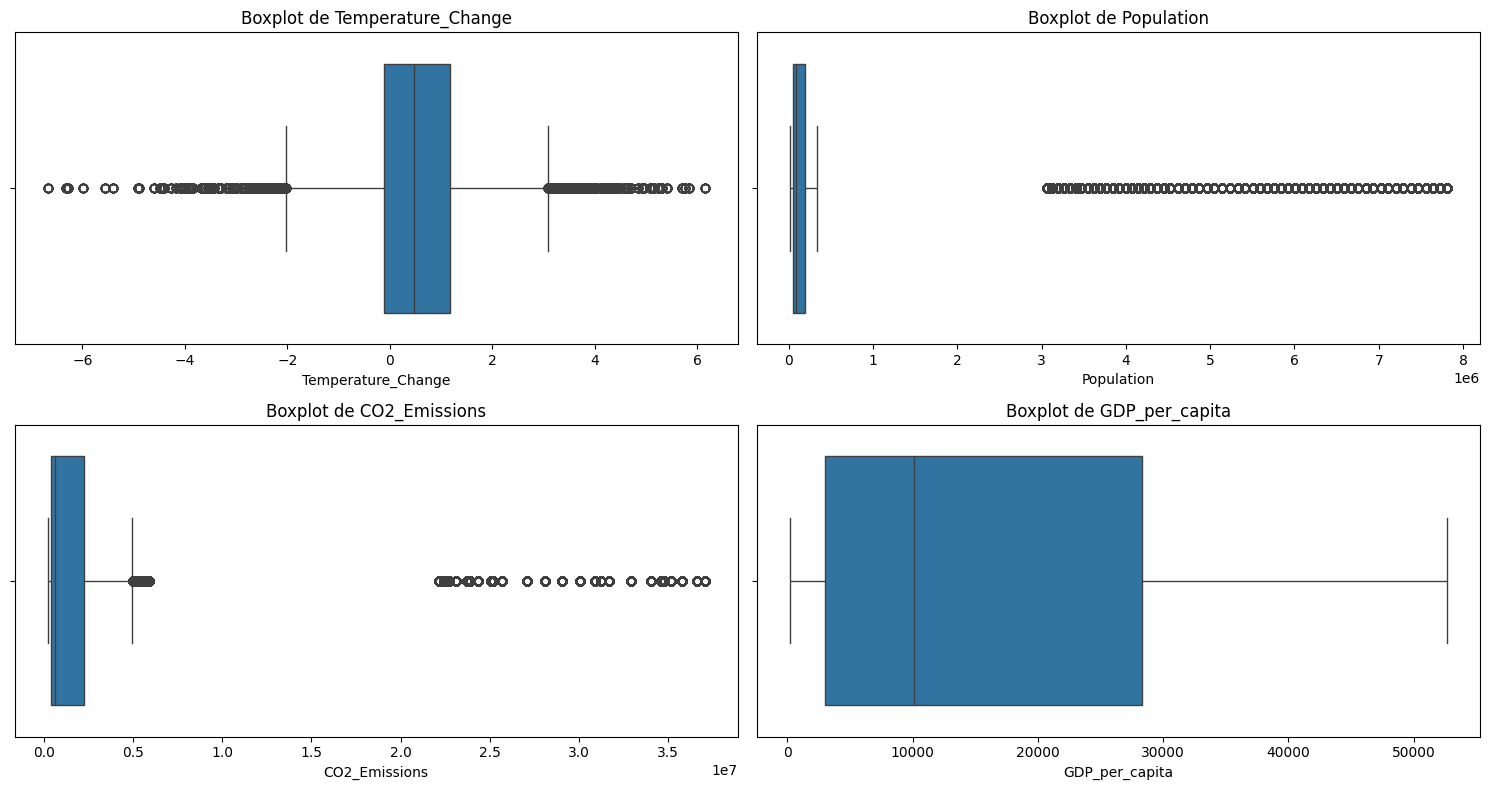


Outliers em Temperature_Change: 6120


,Country,Year,Temperature_Change
17357,Canada,1962,-3.09
17358,Canada,1962,-3.09
17359,Canada,1962,-3.09
17360,Canada,1962,-3.09
17361,Canada,1962,-3.09
...,...,...,...
135570,United States of America,2017,3.53
135571,United States of America,2017,3.53
135572,United States of America,2017,3.53
135573,United States of America,2017,3.53



Outliers em Population: 17051


,Country,Year,Population
136408,World,1961,3064868.76
136409,World,1961,3064868.76
136410,World,1961,3064868.76
136411,World,1961,3064868.76
136412,World,1961,3064868.76
...,...,...,...
153454,World,2019,7811293.16
153455,World,2019,7811293.16
153456,World,2019,7811293.16
153457,World,2019,7811293.16



Outliers em CO2_Emissions: 16762


,Country,Year,CO2_Emissions
128316,United States of America,1992,5017954.16
128317,United States of America,1992,5017954.16
128318,United States of America,1992,5017954.16
128319,United States of America,1992,5017954.16
128320,United States of America,1992,5017954.16
...,...,...,...
153454,World,2019,37037100.92
153455,World,2019,37037100.92
153456,World,2019,37037100.92
153457,World,2019,37037100.92



Outliers em GDP_per_capita: 0


In [123]:
# Detecção de outliers
plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df_final[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

# Identificação dos outliers
for col in num_cols:
    q1 = df_final[col].quantile(0.25)
    q3 = df_final[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    
    outliers = df_final[(df_final[col] < lower_bound) | (df_final[col] > upper_bound)]
    print(f"\nOutliers em {col}: {len(outliers)}")
    if len(outliers) > 0:
        display(outliers[['Country', 'Year', col]])

# 3. Pré-processamento Avançado
Nesta seção faremos o tratamento de dados ausentes, outliers e criação de novas variáveis para análise.

### 3.1 Tratamento de Dados Ausentes

In [124]:
print("\n--- Estratégia para Dados Ausentes ---")

# 1. Para Population e GDP_per_capita (mesmos registros ausentes)
df_final.dropna(subset=['Population'], inplace=True)

# 2. Para CO2_Emissions (imputação por grupo)
df_final['CO2_Emissions'] = df_final.groupby(['Country', 'Months Code'])['CO2_Emissions'].transform(
    lambda x: x.fillna(x.mean()))

# Verificar resultado
print("\nValores ausentes após tratamento:")
print(df_final.isnull().sum())



--- Estratégia para Dados Ausentes ---

Valores ausentes após tratamento:
Area Code                              0
Country                                0
Months Code                            0
Months                                 0
Element Code                           0
Element                                0
Unit                                   0
Year                                   0
Temperature_Change                     0
Population                             0
CO2_Emissions                          0
GDP_per_capita                     17051
CO2_Emissions_diff                 67184
GDP_per_capita_diff                17170
Temperature_Change_rolling_mean        0
CO2_per_capita                     67048
CO2_per_capita_rolling_mean        67048
GDP_global                             0
GDP_vs_global                      17051
dtype: int64


## 3.2 Criação de Novas Variáveis
Variáveis per capita e normalizadas

In [125]:


# Primeiro, tratar possíveis valores nulos em GDP_per_capita
df_final['GDP_per_capita'] = df_final['GDP_per_capita'].fillna(-1)  # Valor temporário

# Agora criar as condições
conditions = [
    df_final['GDP_per_capita'] < 5000,
    (df_final['GDP_per_capita'] >= 5000) & (df_final['GDP_per_capita'] < 20000),
    df_final['GDP_per_capita'] >= 20000
]
choices = ['Low-income', 'Middle-income', 'High-income']

# Criar a nova coluna com um valor default para os casos não cobertos
df_final['Income_Group'] = np.select(conditions, choices, default='Unknown')

# Voltar os valores -1 para NaN
df_final['GDP_per_capita'] = df_final['GDP_per_capita'].replace(-1, np.nan)
df_final['Income_Group'] = df_final['Income_Group'].replace('Unknown', np.nan)

# Verificar o resultado
print("\nDistribuição dos grupos de renda:")
print(df_final['Income_Group'].value_counts(dropna=False))

# Mostrar algumas linhas
display(df_final[['Country', 'Year', 'GDP_per_capita', 'Income_Group']].head())


Distribuição dos grupos de renda:
Income_Group
Low-income       58667
High-income      43639
Middle-income    34102
Name: count, dtype: int64


,Country,Year,GDP_per_capita,Income_Group
0,Brazil,1961,231.56,Low-income
1,Brazil,1961,231.56,Low-income
2,Brazil,1961,231.56,Low-income
3,Brazil,1961,231.56,Low-income
4,Brazil,1961,231.56,Low-income


### 3.3 Tratamento Final para GDP_per_capita


--- Tratamento para GDP_per_capita ---

Países/anos com GDP_per_capita ausente:
                         Country  Year
119357  United States of America  1961
119646  United States of America  1962
119935  United States of America  1963
120224  United States of America  1964
120513  United States of America  1965
120802  United States of America  1966
121091  United States of America  1967
121380  United States of America  1968
121669  United States of America  1969
121958  United States of America  1970
122247  United States of America  1971
122536  United States of America  1972
122825  United States of America  1973
123114  United States of America  1974
123403  United States of America  1975
123692  United States of America  1976
123981  United States of America  1977
124270  United States of America  1978
124559  United States of America  1979
124848  United States of America  1980
125137  United States of America  1981
125426  United States of America  1982
125715  United States 

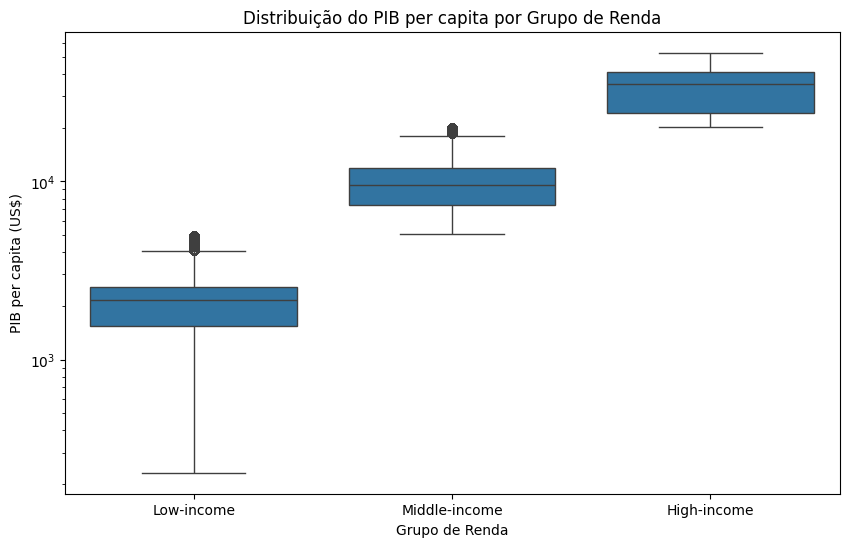

In [126]:
# --- Estratégia para GDP_per_capita faltantes ---
print("\n--- Tratamento para GDP_per_capita ---")

# 1. Ver distribuição por país/ano
print("\nPaíses/anos com GDP_per_capita ausente:")
missing_gdp = df_final[df_final['GDP_per_capita'].isna()]
print(missing_gdp[['Country', 'Year']].drop_duplicates())

# 2. Imputação por médias de países similares
# Criar grupos de referência baseados em Income_Group quando disponível
df_final['GDP_per_capita'] = df_final.groupby(['Country', 'Months Code'])['GDP_per_capita'].transform(
    lambda x: x.fillna(x.mean()))

# Para os restantes, usar média do grupo de renda
df_final['GDP_per_capita'] = df_final.groupby('Income_Group')['GDP_per_capita'].transform(
    lambda x: x.fillna(x.mean()))

# Se ainda houver missing, usar média global
df_final['GDP_per_capita'] = df_final['GDP_per_capita'].fillna(df_final['GDP_per_capita'].mean())

# 3. Reclassificar os grupos de renda
bins = [-np.inf, 5000, 20000, np.inf]
labels = ['Low-income', 'Middle-income', 'High-income']
df_final['Income_Group'] = pd.cut(df_final['GDP_per_capita'], 
                                bins=bins, 
                                labels=labels,
                                right=False)

# 4. Verificar resultados
print("\nValores ausentes após tratamento final:")
print(df_final.isnull().sum())

print("\nNova distribuição dos grupos de renda:")
print(df_final['Income_Group'].value_counts(dropna=False))

# 5. Visualizar distribuição
plt.figure(figsize=(10, 6))
sns.boxplot(x='Income_Group', y='GDP_per_capita', data=df_final, order=labels)
plt.title('Distribuição do PIB per capita por Grupo de Renda')
plt.xlabel('Grupo de Renda')
plt.ylabel('PIB per capita (US$)')
plt.yscale('log')  # Para melhor visualização da ampla faixa de valores
plt.show()

### Estratégia de Imputação para GDP_per_capita
- Primeiro preenchimento usando médias específicas por país e período
- Para países sem histórico, uso da média do grupo de renda
- Como último recurso, utilização da média global
- Todos os valores foram reclassificados após imputação

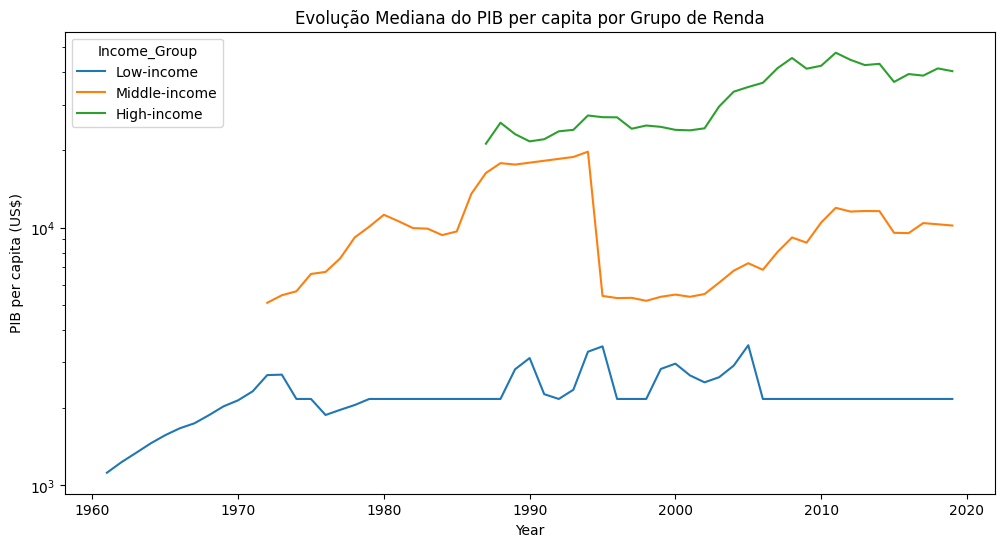

In [127]:
# Gráfico de evolução do PIB por grupo
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_final, x='Year', y='GDP_per_capita', hue='Income_Group', 
             estimator='median', errorbar=None)
plt.title('Evolução Mediana do PIB per capita por Grupo de Renda')
plt.ylabel('PIB per capita (US$)')
plt.yscale('log')
plt.show()

### 3.4 Correção das Features Temporais

In [128]:
# --- Correção das Features Temporais ---
print("\n--- Correção das Features Temporais ---")

# Primeiro criar as colunas de diferença
df_final = df_final.sort_values(['Country', 'Year'])
for col in ['Temperature_Change', 'CO2_Emissions', 'GDP_per_capita']:
    df_final[f'{col}_diff'] = df_final.groupby('Country')[col].diff()

# Criar coluna CO2_per_capita se não existir
if 'CO2_per_capita' not in df_final.columns:
    df_final['CO2_per_capita'] = df_final['CO2_Emissions'] / (df_final['Population'] / 1e6)  # Emissões per capita (por milhão de habitantes)

# Agora preencher diferenças iniciais com 0
for col in ['Temperature_Change_diff', 'CO2_Emissions_diff', 'GDP_per_capita_diff']:
    df_final[col] = df_final[col].fillna(0)

# Recalcular médias móveis garantindo janela completa
window_size = 5
for col in ['Temperature_Change', 'CO2_per_capita']:
    df_final[f'{col}_rolling_mean'] = df_final.groupby('Country')[col].transform(
        lambda x: x.rolling(window_size, min_periods=1).mean())

# Verificar correção
print("\nVerificação após correção:")
display(df_final[['Country', 'Year', 'Temperature_Change_diff', 'Temperature_Change_rolling_mean', 'CO2_per_capita', 'CO2_per_capita_rolling_mean']].head(10))


--- Correção das Features Temporais ---

Verificação após correção:


,Country,Year,Temperature_Change_diff,Temperature_Change_rolling_mean,CO2_per_capita,CO2_per_capita_rolling_mean
0,Brazil,1961,0.00,-0.11,NaN,NaN
1,Brazil,1961,0.00,-0.11,NaN,NaN
2,Brazil,1961,0.00,-0.11,NaN,NaN
3,Brazil,1961,0.00,-0.11,NaN,NaN
4,Brazil,1961,0.00,-0.11,NaN,NaN
5,Brazil,1961,0.00,-0.11,NaN,NaN
6,Brazil,1961,0.00,-0.11,NaN,NaN
7,Brazil,1961,0.00,-0.11,NaN,NaN
8,Brazil,1961,0.00,-0.11,NaN,NaN
9,Brazil,1961,0.00,-0.11,NaN,NaN


### 3.5 Features Geográficas Aprimoradas

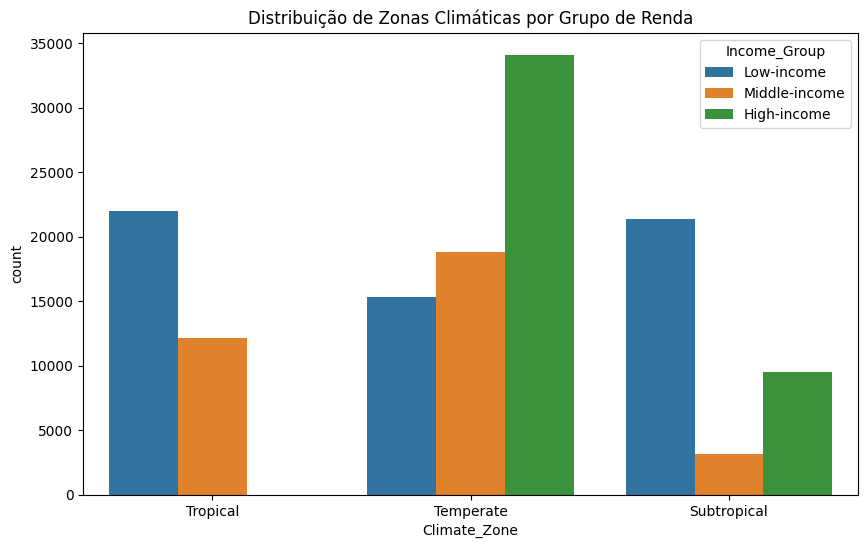

In [129]:

# --- Adicionando latitude primeiro ---
country_latitudes = {
    'Brazil': -10, 'Canada': 60, 'France': 46, 
    'Germany': 51, 'Italy': 42, 'Japan': 36,
    'United Kingdom': 55, 'United States of America': 37, 'World': 0
}
df_final['Latitude'] = df_final['Country'].map(country_latitudes)

# --- Adicionando zonas climáticas ---
def classify_climate(lat):
    if abs(lat) <= 23.5: return 'Tropical'
    elif 23.5 < abs(lat) <= 40: return 'Subtropical'
    elif 40 < abs(lat) <= 60: return 'Temperate'
    else: return 'Polar'

df_final['Climate_Zone'] = df_final['Latitude'].apply(classify_climate)

# Verificar se Income_Group existe antes de plotar
if 'Income_Group' in df_final.columns:
    # Visualizar distribuição
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_final, x='Climate_Zone', hue='Income_Group')
    plt.title('Distribuição de Zonas Climáticas por Grupo de Renda')
    plt.show()
else:
    print("A coluna 'Income_Group' não foi encontrada. Execute primeiro a criação dos grupos de renda.")

In [130]:
# Verificação de colunas esperadas
required_columns = ['Temperature_Change_diff', 'CO2_per_capita_rolling_mean', 'Latitude']
missing = [col for col in required_columns if col not in df_final.columns]
if missing:
    print(f"\nAtenção: Colunas faltantes - {missing}")
else:
    print("\nTodas as colunas necessárias foram criadas com sucesso!")


Todas as colunas necessárias foram criadas com sucesso!


# 4. Engenharia de Features Avançada
Criação de variáveis temporais e agregações para enriquecer o modelo.

In [131]:

# --- 4.0 Seleção e Transformação de Features ---
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Definir features
features = {
    'numeric': ['Population', 'CO2_per_capita', 'GDP_per_capita', 
                'Temperature_Change_diff', 'Temperature_Change_rolling_mean',
                'Latitude'],
    'categorical': ['Income_Group', 'Climate_Zone']
}

# Criar transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features['numeric']),
        ('cat', OneHotEncoder(drop='first'), features['categorical'])
    ])

# Aplicar transformações
X = df_final[features['numeric'] + features['categorical']]
y = df_final['Temperature_Change']

X_processed = preprocessor.fit_transform(X)

# Verificar resultado
print("\nShape após pré-processamento:", X_processed.shape)
print("\nNomes das features após transformação:")
print(preprocessor.get_feature_names_out())


Shape após pré-processamento: (136408, 10)

Nomes das features após transformação:
['num__Population' 'num__CO2_per_capita' 'num__GDP_per_capita'
 'num__Temperature_Change_diff' 'num__Temperature_Change_rolling_mean'
 'num__Latitude' 'cat__Income_Group_Low-income'
 'cat__Income_Group_Middle-income' 'cat__Climate_Zone_Temperate'
 'cat__Climate_Zone_Tropical']


### 4.1 Features Temporais
Diferença anual para cada variável

In [132]:

df_final = df_final.sort_values(['Country', 'Year'])
for col in ['Temperature_Change', 'CO2_Emissions', 'GDP_per_capita']:
    df_final[f'{col}_diff'] = df_final.groupby('Country')[col].diff()

# Médias móveis (janela de 5 anos)
window_size = 5
for col in ['Temperature_Change', 'CO2_per_capita']:
    df_final[f'{col}_rolling_mean'] = df_final.groupby('Country')[col].transform(
        lambda x: x.rolling(window_size, min_periods=1).mean())



### 4.2 Agregações por Grupo

In [133]:
# Primeiro, criar um dicionário com os valores globais por ano
world_gdp = df_final[df_final['Country']=='World'].set_index('Year')['GDP_per_capita'].to_dict()

# Agora criar a nova coluna dividindo pelo valor global do mesmo ano
df_final['GDP_vs_global'] = df_final.apply(
    lambda row: row['GDP_per_capita'] / world_gdp.get(row['Year'], np.nan), 
    axis=1
)

# Verificar novas features
print("\nNovas features criadas:")
display(df_final.iloc[:, -8:].head())


Novas features criadas:


,CO2_per_capita,CO2_per_capita_rolling_mean,GDP_global,GDP_vs_global,Income_Group,Temperature_Change_diff,Latitude,Climate_Zone
0,NaN,NaN,472.11,0.49,Low-income,NaN,-10,Tropical
1,NaN,NaN,472.11,0.49,Low-income,0.00,-10,Tropical
2,NaN,NaN,472.11,0.49,Low-income,0.00,-10,Tropical
3,NaN,NaN,472.11,0.49,Low-income,0.00,-10,Tropical
4,NaN,NaN,472.11,0.49,Low-income,0.00,-10,Tropical


In [134]:
df_final['CO2_Emissions_diff'] = df_final['CO2_Emissions_diff'].fillna(0)
df_final['GDP_per_capita_diff'] = df_final['GDP_per_capita_diff'].fillna(0)

In [135]:
pd.options.display.float_format = '{:.2f}'.format
display(df_final.iloc[:, -8:].head())

,CO2_per_capita,CO2_per_capita_rolling_mean,GDP_global,GDP_vs_global,Income_Group,Temperature_Change_diff,Latitude,Climate_Zone
0,NaN,NaN,472.11,0.49,Low-income,NaN,-10,Tropical
1,NaN,NaN,472.11,0.49,Low-income,0.00,-10,Tropical
2,NaN,NaN,472.11,0.49,Low-income,0.00,-10,Tropical
3,NaN,NaN,472.11,0.49,Low-income,0.00,-10,Tropical
4,NaN,NaN,472.11,0.49,Low-income,0.00,-10,Tropical


### 4.3 Features Geográficas
Exemplo simplificado (latitude média por país)


In [136]:
country_latitudes = {
    'Brazil': -10, 'Canada': 60, 'France': 46, 
    'Germany': 51, 'Italy': 42, 'Japan': 36,
    'United Kingdom': 55, 'United States of America': 37, 'World': 0
}
df_final['Latitude'] = df_final['Country'].map(country_latitudes)

In [137]:
# %% [markdown]
# # 5. Seleção de Features
# Preparação final dos dados para modelagem.

# %%
# --- 5.1 Seleção de Variáveis ---
features = [
    'Population', 'CO2_per_capita', 'GDP_per_capita', 
    'Temperature_Change_diff', 'CO2_Emissions_diff',
    'Temperature_Change_rolling_mean', 'Latitude',
    'Income_Group'
]

target = 'Temperature_Change'

# Filtrar e preparar dados
model_df = df_final[features + [target]].copy()

# Codificar variáveis categóricas
model_df = pd.get_dummies(model_df, columns=['Income_Group'], drop_first=True)

# Remover linhas com valores ausentes (se houver)
model_df.dropna(inplace=True)

print("\nDataset final para modelagem:")
print(model_df.info())


Dataset final para modelagem:
<class 'pandas.core.frame.DataFrame'>
Index: 69360 entries, 8381 to 153458
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Population                       69360 non-null  float64
 1   CO2_per_capita                   69360 non-null  float64
 2   GDP_per_capita                   69360 non-null  float64
 3   Temperature_Change_diff          69360 non-null  float64
 4   CO2_Emissions_diff               69360 non-null  float64
 5   Temperature_Change_rolling_mean  69360 non-null  float64
 6   Latitude                         69360 non-null  int64  
 7   Temperature_Change               69360 non-null  float64
 8   Income_Group_Middle-income       69360 non-null  bool   
 9   Income_Group_High-income         69360 non-null  bool   
dtypes: bool(2), float64(7), int64(1)
memory usage: 4.9 MB
None
